# 2.5D Triplanar Multi-view Ensemble — BraTS 2020

**전략**: Axial / Coronal / Sagittal 3개 view에서 각각 adjacent 5장 모델 독립 학습 → 확률 맵 평균

```
Volume (192,192,D,4)
    │
    ├─ Axial view    : volume[:, :,  z,  :] × 5 adjacent → (192,192,20) → U-Net-Att → prob_axial
    ├─ Coronal view  : volume[:,  j, :,  :] × 5 adjacent → resize → (192,192,20) → U-Net-Att → prob_coronal
    └─ Sagittal view : volume[ i, :, :,  :] × 5 adjacent → resize → (192,192,20) → U-Net-Att → prob_sagittal
                                                                                          │
                                    prob_axial + prob_coronal + prob_sagittal  → 평균 → 최종 예측
```

---

### ⚠️ 핵심 위험 요소 및 대응

| 위험 | 원인 | 대응 |
|------|------|------|
| Coronal/Sagittal 비정방 | 슬라이스 shape (192,D) D≈130~150 ≠ 192 | zoom으로 (192,192)로 resize |
| Mask resize 오염 | bilinear interpolation → 소수점 label | order=0 (nearest neighbor) 강제 |
| 3D 재조합 resize 역변환 | 예측 (192,192,3) → 원래 (192,D,3) 복원 | zoom factor = D/192 |
| View별 빈 slice 비율 다름 | 뇌가 구형 → Coronal/Sagittal 가장자리 비어있음 | View별 별도 brain_thr 적용 |
| 학습 시간 3배 | 3개 모델 독립 학습 | 동일 아키텍처, BATCH/EPOCH 조정 |
| 앙상블 불균형 | view별 val Dice 편차 | 가중 평균 (val Dice 비례) 지원 |
| 메모리 (3D 재조합 시) | (192,192,155,3) × float32 = ~70MB × 3 view | float16으로 중간 저장 |

In [11]:
import subprocess, sys
for pkg in ['nibabel', 'monai', 'scikit-learn']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('✓ 설치 완료')

✓ 설치 완료


In [12]:
import os, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

import nibabel as nib
from scipy.ndimage import zoom
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('✓ Device: mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'✓ Device: cuda ({torch.cuda.get_device_name()})')
else:
    DEVICE = torch.device('cpu')
    print('Device: cpu')
print(f'PyTorch: {torch.__version__}')

✓ Device: mps
PyTorch: 2.12.0


In [22]:
# ── 경로 ──────────────────────────────────────────────────────
candidates = [
    Path.home() / 'Desktop' / 'brats_work' / 'brats20-dataset-training-validation',
    Path.home() / 'Downloads' / 'brats20-dataset-training-validation',
    Path.cwd() / 'brats20-dataset-training-validation',
    Path('/kaggle/input/brats20-dataset-training-validation'),
]
DATA_ROOT = next((p for p in candidates if p.exists()), None)
if DATA_ROOT is None:
    raise FileNotFoundError('BraTS 데이터 경로를 찾을 수 없습니다.')

TRAIN_DIR  = DATA_ROOT / 'BraTS2020_TrainingData' / 'MICCAI_BraTS2020_TrainingData'
WORK_DIR   = Path.home() / 'brats_work'
PROC_DIR   = WORK_DIR / 'processed_3d'         # notebook 03과 공용 전처리 폴더
WORK_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

# ── 하이퍼파라미터 ────────────────────────────────────────────
IMG_SIZE        = 192
N_MODALITY      = 4
N_CLASSES       = 3
N_ADJ           = 2                             # ±2 → 5장
IN_CHANNELS     = N_MODALITY * (2*N_ADJ+1)     # 20
BRAIN_VOXEL_THR = 500
CACHE_SIZE      = 260

# 각 view별 배치/에폭 (3개 모델이라 epoch 줄임)
BATCH_SIZE   = 8
LR           = 2e-4
WEIGHT_DECAY = 1e-5
N_EPOCHS     = 40
PATIENCE     = 10
DROPOUT_P    = 0.3
USE_AMP      = (DEVICE.type == 'cuda')

VIEWS = ['axial', 'coronal', 'sagittal']
print(f'IN_CHANNELS={IN_CHANNELS}, VIEWS={VIEWS}')

IN_CHANNELS=20, VIEWS=['axial', 'coronal', 'sagittal']


## 1. 환자 Split (notebook 03과 동일 CSV 재사용)

> `processed_3d/patient_split.csv`가 없으면 새로 생성.
> **반드시 동일 seed(42)** — 2D/U-Net++와 동일한 train/val/test 환자 분리 보장.

In [14]:
MODALITIES = ['flair','t1ce','t1','t2']

def verify_patient(d):
    pid = d.name
    return all((d / f'{pid}_{m}.nii').exists() for m in MODALITIES + ['seg'])

all_dirs   = sorted(d for d in TRAIN_DIR.iterdir() if d.is_dir())
valid_dirs = [d for d in all_dirs if verify_patient(d)]
print(f'전체: {len(all_dirs)}, 유효: {len(valid_dirs)}')

split_csv = PROC_DIR / 'patient_split.csv'
if split_csv.exists():
    split_df = pd.read_csv(split_csv)
    print(f'✓ 기존 split 로드')
else:
    names = [d.name for d in valid_dirs]
    tr,tmp  = train_test_split(names, test_size=0.3, random_state=SEED)
    va,te   = train_test_split(tmp,   test_size=0.667, random_state=SEED)
    split_df = pd.DataFrame({'patient':names,
                             'split':['train' if n in tr else ('val' if n in va else 'test') for n in names]})
    split_df.to_csv(split_csv, index=False)
    print('✓ 새 split 저장')

cnt = split_df['split'].value_counts()
print(f'Train:{cnt.get("train",0)}, Val:{cnt.get("val",0)}, Test:{cnt.get("test",0)}')
pdir_map  = {d.name: d for d in valid_dirs}
split_map = dict(zip(split_df['patient'], split_df['split']))

전체: 369, 유효: 368
✓ 기존 split 로드
Train:257, Val:36, Test:75


## 2. 전처리 — notebook 03과 동일 npz 공용

> `processed_3d/{split}/{pid}.npz`가 이미 있으면 스킵.  
> notebook 03을 먼저 실행했다면 이미 완료된 상태.
>
> **저장 형식**:  
> - `image`:  float16 (192, 192, D, 4) — HW crop+resize 192×192, Z-score 정규화  
> - `mask`:   uint8   (192, 192, D, 3) — WT/TC/ET binary  
> - `valid_axial`: int16 (N,) — brain voxel ≥ threshold인 axial z 인덱스

In [15]:
def load_volume(pdir):
    pid  = pdir.name
    imgs = [nib.load(pdir/f'{pid}_{m}.nii').get_fdata(dtype=np.float32) for m in MODALITIES]
    seg  = nib.load(pdir/f'{pid}_seg.nii').get_fdata(dtype=np.float32)
    return np.stack(imgs, axis=-1), seg

def zscore_normalize(image):
    out = np.zeros_like(image)
    for c in range(image.shape[-1]):
        v = image[...,c]; bm = v > 0
        if bm.sum() == 0: continue
        out[...,c] = (v - v[bm].mean()) / (v[bm].std() + 1e-8) * bm
    return out

def get_brain_bbox(image, margin=5):
    brain = image.sum(axis=-1) > 0
    rr = np.any(brain, axis=(1,2)); cc = np.any(brain, axis=(0,2))
    r0,r1 = np.where(rr)[0][[0,-1]]; c0,c1 = np.where(cc)[0][[0,-1]]
    H,W = image.shape[:2]
    return (max(0,r0-margin),min(H-1,r1+margin),max(0,c0-margin),min(W-1,c1+margin))

def crop_resize(image, mask, bbox, size=192):
    r0,r1,c0,c1 = bbox
    ic = image[r0:r1+1, c0:c1+1, :, :]   # (h,w,D,4)
    mc = mask [r0:r1+1, c0:c1+1, :]
    h,w = ic.shape[:2]; sh,sw = size/h, size/w
    ir = np.stack([zoom(ic[...,c],(sh,sw,1),order=1) for c in range(N_MODALITY)],axis=-1)
    mr = zoom(mc,(sh,sw,1),order=0)
    return ir.astype(np.float32), mr.astype(np.float32)

def mask_to_regions(mask):
    wt = (mask>0).astype(np.uint8)
    tc = ((mask==1)|(mask==4)).astype(np.uint8)
    et = (mask==4).astype(np.uint8)
    return np.stack([wt,tc,et],axis=-1)

def preprocess_patient(pdir, split):
    pid      = pdir.name
    out_dir  = PROC_DIR / split
    out_dir.mkdir(parents=True, exist_ok=True)
    npz_path = out_dir / f'{pid}.npz'
    if npz_path.exists(): return 'skip'
    try:
        img,seg  = load_volume(pdir)
        img      = zscore_normalize(img)
        bbox     = get_brain_bbox(img)
        img,seg  = crop_resize(img,seg,bbox,IMG_SIZE)
        mask_reg = mask_to_regions(seg)
        D        = img.shape[2]
        valid_z  = [z for z in range(D)
                    if (img[:,:,z,:].sum(axis=-1)>0).sum() >= BRAIN_VOXEL_THR]
        np.savez_compressed(npz_path,
                            image       = img.astype(np.float16),
                            mask        = mask_reg,
                            valid_axial = np.array(valid_z,dtype=np.int16))
        return 'ok'
    except Exception as e:
        print(f'[ERROR] {pdir.name}: {e}'); return 'error'

print('전처리 시작 (notebook 03 완료 시 전부 skip)')
stats = {'ok':0,'skip':0,'error':0}
for pid,sp in tqdm(split_map.items(), desc='전처리'):
    r = preprocess_patient(pdir_map[pid], sp)
    stats[r] += 1
print('✓ 완료:', stats)

전처리 시작 (notebook 03 완료 시 전부 skip)


전처리: 100%|██████████| 368/368 [00:00<00:00, 81905.22it/s]

✓ 완료: {'ok': 0, 'skip': 368, 'error': 0}


## 3. View별 Dataset

### View별 슬라이스 추출 방식

| View | 슬라이스 axis | 원본 shape | Resize 필요 | 슬라이스 수/환자 |
|------|--------------|-----------|------------|-----------------|
| Axial | D (depth, z) | (192,192,4) | 불필요 | D ≈ 130~150 |
| Coronal | W (width, j) | (192,D,4) | (192,D)→(192,192) | W=192 |
| Sagittal | H (height, i) | (192,D,4) | (192,D)→(192,192) | H=192 |

### Adjacent slice 경계 처리 (edge-replicate)
```
z_idx = np.clip([z-2, z-1, z, z+1, z+2], 0, N_slices-1)
# 예: z=0 → [-2,-1,0,1,2] → clip → [0,0,0,1,2]
```

### Resize 시 주의
- **이미지**: `order=1` (bilinear) — 연속값 보존
- **마스크**: `order=0` (nearest neighbor) — label 정수값 보존

In [23]:
def resize_slice_img(sl, target_h, target_w):
    """(h, w, C) → (target_h, target_w, C) — bilinear."""
    h, w, C = sl.shape
    if h == target_h and w == target_w: return sl
    factors = (target_h/h, target_w/w, 1)
    return zoom(sl, factors, order=1).astype(np.float32)

def resize_slice_mask(sl, target_h, target_w):
    """(h, w, C) → nearest — label 보존."""
    h, w, C = sl.shape
    if h == target_h and w == target_w: return sl
    factors = (target_h/h, target_w/w, 1)
    return zoom(sl.astype(np.float32), factors, order=0).astype(np.float32)


class MultiViewDataset(Dataset):
    """
    view: 'axial' | 'coronal' | 'sagittal'
    
    공통: adjacent N_ADJ slices 스택 → (192,192,IN_CHANNELS)
    Coronal/Sagittal: resize 적용 후 스택
    """
    def __init__(self, proc_dir, split, view='axial',
                 n_adj=N_ADJ, oversample=0.7, augment=False):
        assert view in VIEWS
        self.proc_dir  = proc_dir / split
        self.split     = split
        self.view      = view
        self.n_adj     = n_adj
        self.oversample= oversample
        self.augment   = augment
        self._cache    = {}
        self._order    = []

        self.tumor_samples = []
        self.other_samples = []

        for npz_path in tqdm(sorted(self.proc_dir.glob('*.npz')),
                             desc=f'[{split}/{view}] 인덱스', leave=False):
            pid  = npz_path.stem
            data = self._load(pid, npz_path)
            img  = data['image']   # (192,192,D,4)
            msk  = data['mask']    # (192,192,D,3)
            H,W,D,_ = img.shape

            if view == 'axial':
                slices_range = data['valid_axial'].tolist()
                N_slices     = D
                for z in slices_range:
                    has_t = bool(msk[:,:,z,:].sum() > 0)
                    (self.tumor_samples if has_t else self.other_samples).append((pid,z,N_slices,'axial'))

            elif view == 'coronal':
                # 슬라이스 along W axis: img[:, j, :, :] → (H,D,4)
                N_slices = W
                for j in range(W):
                    sl_brain = img[:,j,:,:].sum(axis=-1)
                    if (sl_brain > 0).sum() < BRAIN_VOXEL_THR: continue
                    has_t = bool(msk[:,j,:,:].sum() > 0)
                    (self.tumor_samples if has_t else self.other_samples).append((pid,j,N_slices,'coronal'))

            else:  # sagittal
                # 슬라이스 along H axis: img[i, :, :, :] → (W,D,4)
                N_slices = H
                for i in range(H):
                    sl_brain = img[i,:,:,:].sum(axis=-1)
                    if (sl_brain > 0).sum() < BRAIN_VOXEL_THR: continue
                    has_t = bool(msk[i,:,:,:].sum() > 0)
                    (self.tumor_samples if has_t else self.other_samples).append((pid,i,N_slices,'sagittal'))

        self.all_samples = self.tumor_samples + self.other_samples
        nt,no = len(self.tumor_samples), len(self.other_samples)
        print(f'[{split}/{view}] {len(self.all_samples)} slices '
              f'(종양:{nt} ({100*nt/max(1,nt+no):.1f}%), 비종양:{no})')

    def _load(self, pid, path=None):
        if pid not in self._cache:
            if len(self._cache) >= CACHE_SIZE:
                evict = self._order.pop(0); del self._cache[evict]
            raw = np.load(path or (self.proc_dir/f'{pid}.npz'))
            self._cache[pid] = {
                'image':       raw['image'].astype(np.float32),
                'mask':        raw['mask'].astype(np.float32),
                'valid_axial': raw['valid_axial']
            }
            self._order.append(pid)
        else:
            self._order.remove(pid); self._order.append(pid)
        return self._cache[pid]

    def _extract_stack(self, data, idx, view):
        """
        center idx 기준으로 adjacent slices 추출 + resize + channel 스택.
        반환: img_stack (192,192,20), mask_center (192,192,3)
        """
        img = data['image']; msk = data['mask']
        H,W,D,_ = img.shape

        if view == 'axial':
            N = D
            z_idx = np.clip(np.arange(idx-self.n_adj, idx+self.n_adj+1), 0, N-1)
            slices = [img[:,:,z,:] for z in z_idx]   # list of (192,192,4)
            center_mask = msk[:,:,idx,:]

        elif view == 'coronal':
            N = W
            j_idx = np.clip(np.arange(idx-self.n_adj, idx+self.n_adj+1), 0, N-1)
            raw   = [img[:,j,:,:] for j in j_idx]    # list of (H,D,4) non-square
            # Resize each to (192,192,4) — bilinear
            slices = [resize_slice_img(s, IMG_SIZE, IMG_SIZE) for s in raw]
            # Center mask: (H,D,3) → resize → (192,192,3) nearest
            center_mask = resize_slice_mask(msk[:,idx,:,:], IMG_SIZE, IMG_SIZE)

        else:  # sagittal
            N = H
            i_idx = np.clip(np.arange(idx-self.n_adj, idx+self.n_adj+1), 0, N-1)
            raw   = [img[i,:,:,:] for i in i_idx]    # list of (W,D,4) non-square
            slices = [resize_slice_img(s, IMG_SIZE, IMG_SIZE) for s in raw]
            center_mask = resize_slice_mask(msk[idx,:,:,:], IMG_SIZE, IMG_SIZE)

        img_stack = np.concatenate(slices, axis=-1)   # (192,192,20)
        return img_stack, center_mask

    def _augment(self, img, mask):
        if random.random() < 0.5:
            img=img[:,::-1,:].copy(); mask=mask[:,::-1,:].copy()
        if random.random() < 0.5:
            img=img[::-1,:,:].copy(); mask=mask[::-1,:,:].copy()
        if random.random() < 0.3:
            k=random.choice([1,2,3])
            img=np.rot90(img,k,(0,1)).copy(); mask=np.rot90(mask,k,(0,1)).copy()
        if random.random() < 0.3:
            img = img + np.random.normal(0,0.05,img.shape).astype(np.float32)
        return img, mask

    def __len__(self): return len(self.all_samples)

    def __getitem__(self, raw_idx):
        if self.split=='train' and self.tumor_samples and random.random()<self.oversample:
            pid,idx,_,view = random.choice(self.tumor_samples)
        elif self.split=='train' and self.other_samples:
            pid,idx,_,view = random.choice(self.other_samples)
        else:
            pid,idx,_,view = self.all_samples[raw_idx]

        data = self._load(pid)
        img5, center_msk = self._extract_stack(data, idx, view)

        if self.augment:
            img5, center_msk = self._augment(img5, center_msk)

        img_t  = torch.from_numpy(img5).permute(2,0,1).float()
        mask_t = torch.from_numpy(center_msk).permute(2,0,1).float()
        return img_t, mask_t


print('✓ MultiViewDataset 정의 완료')

✓ MultiViewDataset 정의 완료


## 4. 공유 모델 — Attention U-Net (3 view 모두 동일 아키텍처)

U-Net++보다 단순한 표준 U-Net + Attention Gate 사용.  
이유: 3개 모델을 학습해야 하므로 파라미터/학습 시간 균형 고려.  
앙상블 이득은 아키텍처 복잡도가 아닌 **view 다양성**에서 발생.

In [17]:
NUM_GROUPS = 8

class SEBlock(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        mid = max(ch//r, 4)
        self.se = nn.Sequential(nn.AdaptiveAvgPool2d(1),nn.Flatten(),
                                 nn.Linear(ch,mid),nn.ReLU(inplace=True),
                                 nn.Linear(mid,ch),nn.Sigmoid())
    def forward(self,x):
        return x * self.se(x).view(x.shape[0],x.shape[1],1,1)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_x, F_mid):
        super().__init__()
        self.Wg  = nn.Sequential(nn.Conv2d(F_g,F_mid,1,bias=False),
                                  nn.GroupNorm(NUM_GROUPS,F_mid))
        self.Wx  = nn.Sequential(nn.Conv2d(F_x,F_mid,1,bias=False),
                                  nn.GroupNorm(NUM_GROUPS,F_mid))
        self.psi = nn.Sequential(nn.Conv2d(F_mid,1,1,bias=False),
                                  nn.GroupNorm(1,1),nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self,g,x):
        return x * self.psi(self.relu(self.Wg(g)+self.Wx(x)))

class DoubleConv(nn.Module):
    def __init__(self,in_ch,out_ch,dropout=0.0):
        super().__init__()
        layers=[nn.Conv2d(in_ch,out_ch,3,padding=1,bias=False),
                nn.GroupNorm(NUM_GROUPS,out_ch),nn.ReLU(inplace=True),
                nn.Conv2d(out_ch,out_ch,3,padding=1,bias=False),
                nn.GroupNorm(NUM_GROUPS,out_ch),nn.ReLU(inplace=True)]
        if dropout>0: layers.append(nn.Dropout2d(dropout))
        self.conv=nn.Sequential(*layers)
    def forward(self,x): return self.conv(x)

class AttUNet(nn.Module):
    """표준 U-Net + SE encoder + Attention Gate skip connections."""
    def __init__(self, in_ch=IN_CHANNELS, n_cls=N_CLASSES,
                 feats=(32,64,128,256,512), dropout=DROPOUT_P):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        # Encoder
        self.enc  = nn.ModuleList()
        self.se   = nn.ModuleList()
        prev = in_ch
        for i,f in enumerate(feats):
            dp = dropout if i==len(feats)-1 else 0.0
            self.enc.append(DoubleConv(prev,f,dropout=dp))
            self.se.append(SEBlock(f))
            prev = f
        # Decoder
        self.dec_ups  = nn.ModuleList()   # transposed conv
        self.att_gates= nn.ModuleList()
        self.dec_convs= nn.ModuleList()
        for i in range(len(feats)-1):
            hi = len(feats)-2-i          # 3,2,1,0
            f_up = feats[hi+1]; f_lo = feats[hi]
            self.dec_ups.append(
                nn.Sequential(nn.Upsample(scale_factor=2,mode='bilinear',align_corners=True),
                               nn.Conv2d(f_up,f_lo,1,bias=False)))
            self.att_gates.append(AttentionGate(f_lo,f_lo,max(f_lo//2,NUM_GROUPS)))
            self.dec_convs.append(DoubleConv(f_lo*2,f_lo))
        self.out = nn.Conv2d(feats[0],n_cls,1)

    def forward(self,x):
        skips=[]
        for enc,se in zip(self.enc,self.se):
            x=enc(x); x=se(x); skips.append(x)
            if enc is not self.enc[-1]: x=self.pool(x)
        skips=skips[:-1][::-1]   # [enc3,enc2,enc1,enc0]
        for up,att,dec,sk in zip(self.dec_ups,self.att_gates,self.dec_convs,skips):
            x = up(x)
            sk_att = att(x,sk)
            x = dec(torch.cat([x,sk_att],dim=1))
        return self.out(x)


def build_model():
    m = AttUNet().to(DEVICE)
    dummy = torch.zeros(2,IN_CHANNELS,IMG_SIZE,IMG_SIZE).to(DEVICE)
    with torch.no_grad(): o = m(dummy)
    n = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'파라미터: {n/1e6:.1f}M, 출력: {o.shape}')
    return m

_ = build_model()
print('✓ AttUNet 정의 완료')

파라미터: 7.4M, 출력: torch.Size([2, 3, 192, 192])
✓ AttUNet 정의 완료


In [18]:
class DiceBCELoss(nn.Module):
    def __init__(self,dw=0.5,bw=0.5):
        super().__init__()
        self.dw,self.bw=dw,bw
        self.bce=nn.BCEWithLogitsLoss()
    def forward(self,pred,target):
        p=torch.sigmoid(pred); smooth=1e-6
        dims=tuple(range(2,pred.ndim))
        dice=1-((2*(p*target).sum(dim=dims)+smooth)/
                (p.sum(dim=dims)+target.sum(dim=dims)+smooth)).mean()
        return self.dw*dice + self.bw*self.bce(pred,target)

@torch.no_grad()
def dice_scores(logits,target,thr=0.5):
    pred=(torch.sigmoid(logits)>thr).float(); smooth=1e-6; scores={}
    for i,n in enumerate(['WT','TC','ET']):
        p=pred[:,i].reshape(-1); t=target[:,i].reshape(-1)
        scores[n]=((2*(p*t).sum()+smooth)/(p.sum()+t.sum()+smooth)).item()
    scores['mean']=float(np.mean(list(scores.values())))
    return scores

def train_one_view(view, n_epochs=N_EPOCHS, patience=PATIENCE):
    """한 view에 대해 전체 학습 사이클 실행. 체크포인트 반환."""
    print(f'\n{"="*60}')
    print(f'  학습 시작: {view.upper()} view')
    print(f'{"="*60}')

    ckpt_path = WORK_DIR / f'ckpt_multiview_{view}.pth'

    ds_tr = MultiViewDataset(PROC_DIR,'train',view=view,augment=True)
    ds_va = MultiViewDataset(PROC_DIR,'val',  view=view)
    loader_tr = DataLoader(ds_tr,BATCH_SIZE,shuffle=True, num_workers=0,pin_memory=True)
    loader_va = DataLoader(ds_va,BATCH_SIZE,shuffle=False,num_workers=0, pin_memory=True)

    model     = build_model()
    optimizer = torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=n_epochs)
    criterion = DiceBCELoss()
    scaler    = torch.cuda.amp.GradScaler() if USE_AMP else None

    best_dice,patience_cnt,history = 0.0,0,[]

    for epoch in range(1,n_epochs+1):
        # ── train ──────────────────────────────────────────────
        model.train(); tr_loss,tr_scores=[],[]
        for imgs,masks in tqdm(loader_tr,desc=f'Ep{epoch:3d} [{view}] Train',leave=False):
            imgs,masks=imgs.to(DEVICE),masks.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            if USE_AMP:
                with torch.cuda.amp.autocast():
                    pred=model(imgs); loss=criterion(pred,masks)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(),1.0)
                scaler.step(optimizer); scaler.update()
            else:
                pred=model(imgs); loss=criterion(pred,masks)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(),1.0)
                optimizer.step()
            tr_loss.append(loss.item())
            tr_scores.append(dice_scores(pred.detach().cpu().float(),masks.cpu().float()))
        # ── val ────────────────────────────────────────────────
        model.eval(); va_loss,va_scores=[],[]
        with torch.no_grad():
            for imgs,masks in tqdm(loader_va,desc=f'Ep{epoch:3d} [{view}] Val  ',leave=False):
                imgs,masks=imgs.to(DEVICE),masks.to(DEVICE)
                pred=model(imgs); va_loss.append(criterion(pred,masks).item())
                va_scores.append(dice_scores(pred.cpu().float(),masks.cpu().float()))

        tr_d=np.mean([s['mean'] for s in tr_scores])
        va_d={k:np.mean([s[k] for s in va_scores]) for k in ['WT','TC','ET','mean']}
        scheduler.step()

        flag=''
        if va_d['mean']>best_dice:
            best_dice=va_d['mean']; patience_cnt=0
            torch.save(model.state_dict(),ckpt_path); flag=' ★'
        else:
            patience_cnt+=1

        history.append({'epoch':epoch,'view':view,
                        'train_dice':tr_d,'val_mean':va_d['mean'],
                        'val_WT':va_d['WT'],'val_TC':va_d['TC'],'val_ET':va_d['ET']})

        print(f'Ep{epoch:3d} [{view}] tr={np.mean(tr_loss):.4f} '
              f'| WT={va_d["WT"]:.4f} TC={va_d["TC"]:.4f} ET={va_d["ET"]:.4f} '
              f'mean={va_d["mean"]:.4f}{flag}')

        if patience_cnt>=patience:
            print(f'  Early stopping (epoch {epoch})'); break

    print(f'  Best Val Dice [{view}]: {best_dice:.4f}  → {ckpt_path}')
    pd.DataFrame(history).to_csv(WORK_DIR/f'history_multiview_{view}.csv',index=False)
    return ckpt_path, best_dice


print('✓ 학습 함수 정의 완료')

✓ 학습 함수 정의 완료


## 5. 3개 View 순차 학습

각 view별로 독립적인 모델을 학습합니다.  
**학습 시간 예상**: View당 약 1-3시간 (GPU P100 기준) → 총 3-9시간

In [19]:
# ── Axial 학습 ────────────────────────────────────────────────
ckpt_axial, dice_axial = train_one_view('axial')
print(f'Axial done: best val dice = {dice_axial:.4f}')


  학습 시작: AXIAL view


[train/axial] 30830 slices (종양:16922 (54.9%), 비종양:13908)


[val/axial] 4173 slices (종양:2304 (55.2%), 비종양:1869)
파라미터: 7.4M, 출력: torch.Size([2, 3, 192, 192])


Ep  1 [axial] tr=0.3633 | WT=0.5428 TC=0.5970 ET=0.6604 mean=0.6001 ★


Ep  2 [axial] tr=0.3018 | WT=0.6869 TC=0.6978 ET=0.7123 mean=0.6990 ★


...

Ep 14 [axial] tr=0.1953 | WT=0.6195 TC=0.6551 ET=0.8532 mean=0.7093


Ep 15 [axial] tr=0.1926 | WT=0.6214 TC=0.6329 ET=0.8660 mean=0.7068


Ep 16 [axial] tr=0.1924 | WT=0.5868 TC=0.6163 ET=0.8610 mean=0.6881


Ep 17 [axial] tr=0.1231 | WT=0.6561 TC=0.8242 ET=0.8718 mean=0.7840


Ep 18 [axial] tr=0.1118 | WT=0.6024 TC=0.8458 ET=0.8745 mean=0.7742
  Early stopping (epoch 18)
  Best Val Dice [axial]: 0.7995  → /Users/hong-igdaebaiohelseu/brats_work/ckpt_multiview_axial.pth
Axial done: best val dice = 0.7995


In [20]:
# ── Coronal 학습 ───────────────────────────────────────────────
ckpt_coronal, dice_coronal = train_one_view('coronal')
print(f'Coronal done: best val dice = {dice_coronal:.4f}')


  학습 시작: CORONAL view


[train/coronal] 43706 slices (종양:23125 (52.9%), 비종양:20581)


[val/coronal] 6140 slices (종양:3101 (50.5%), 비종양:3039)
파라미터: 7.4M, 출력: torch.Size([2, 3, 192, 192])


Ep  1 [coronal] tr=0.3593 | WT=0.5232 TC=0.5058 ET=0.5304 mean=0.5198 ★


Ep  2 [coronal] tr=0.3114 | WT=0.5251 TC=0.6367 ET=0.7345 mean=0.6321 ★


...

Ep 17 [coronal] tr=0.1107 | WT=0.5461 TC=0.8036 ET=0.8912 mean=0.7470


Ep 18 [coronal] tr=0.1093 | WT=0.5711 TC=0.8333 ET=0.8811 mean=0.7618


Ep 19 [coronal] tr=0.1080 | WT=0.5919 TC=0.8113 ET=0.8626 mean=0.7553


Ep 20 [coronal] tr=0.1072 | WT=0.6144 TC=0.8135 ET=0.8888 mean=0.7722


Ep 21 [coronal] tr=0.1058 | WT=0.5637 TC=0.8265 ET=0.8804 mean=0.7569
  Early stopping (epoch 21)
  Best Val Dice [coronal]: 0.7972  → /Users/hong-igdaebaiohelseu/brats_work/ckpt_multiview_coronal.pth
Coronal done: best val dice = 0.7972


In [24]:
# ── Sagittal 학습 ──────────────────────────────────────────────
ckpt_sagittal, dice_sagittal = train_one_view('sagittal')
print(f'Sagittal done: best val dice = {dice_sagittal:.4f}')

# 학습 결과 요약
print('\n' + '='*50)
print('  Multi-view 학습 결과 요약')
print('='*50)
for view,d in zip(VIEWS,[dice_axial,dice_coronal,dice_sagittal]):
    print(f'  {view:10s}: val Dice = {d:.4f}')
print('='*50)


  학습 시작: SAGITTAL view


[train/sagittal] 43036 slices (종양:20681 (48.1%), 비종양:22355)


[val/sagittal] 6103 slices (종양:2880 (47.2%), 비종양:3223)
파라미터: 7.4M, 출력: torch.Size([2, 3, 192, 192])


Ep  1 [sagittal] tr=0.3453 | WT=0.4171 TC=0.4434 ET=0.4456 mean=0.4353 ★


Ep  2 [sagittal] tr=0.3012 | WT=0.4385 TC=0.4542 ET=0.5407 mean=0.4778 ★


...

Ep 23 [sagittal] tr=0.1079 | WT=0.4861 TC=0.8769 ET=0.8778 mean=0.7469


Ep 24 [sagittal] tr=0.1071 | WT=0.5055 TC=0.8753 ET=0.8736 mean=0.7515


Ep 25 [sagittal] tr=0.1066 | WT=0.4962 TC=0.8615 ET=0.8579 mean=0.7385


Ep 26 [sagittal] tr=0.1051 | WT=0.4753 TC=0.8607 ET=0.8678 mean=0.7346


Ep 27 [sagittal] tr=0.1038 | WT=0.4847 TC=0.8731 ET=0.8820 mean=0.7466
  Early stopping (epoch 27)
  Best Val Dice [sagittal]: 0.7608  → /Users/hong-igdaebaiohelseu/brats_work/ckpt_multiview_sagittal.pth
Sagittal done: best val dice = 0.7608

  Multi-view 학습 결과 요약
  axial     : val Dice = 0.7995
  coronal   : val Dice = 0.7972
  sagittal  : val Dice = 0.7608


## 6. Ensemble Inference — 3D 확률 맵 평균

### 3D 재조합 과정

```
각 view별 모델로 slice-by-slice 예측:

Axial model:
  for z in range(D):
    input  = volume[:, :, z-2:z+3, :].stack  → (192,192,20)
    output = model(input)                      → (192,192,3) sigmoid prob
    prob_axial[:, :, z, :] = output            직접 삽입

Coronal model:
  for j in range(W=192):
    input  = volume[:, j-2:j+3, :, :].resize.stack → (192,192,20)
    output = model(input)                            → (192,192,3)
    # 예측은 resize된 공간 → 원래 (192,D) 공간으로 역변환
    output_back = zoom(output, (1, D/192, 1), order=0) → (192,D,3)
    prob_coronal[:, j, :, :] = output_back

Sagittal model:
  for i in range(H=192):
    input  = volume[i-2:i+3, :, :, :].resize.stack → (192,192,20)
    output = model(input)                            → (192,192,3)
    output_back = zoom(output, (1, D/192, 1), order=0) → (192,D,3)
    prob_sagittal[i, :, :, :] = output_back

Ensemble = (w_ax*prob_axial + w_co*prob_coronal + w_sa*prob_sagittal) / (w_ax+w_co+w_sa)
```

### 가중치 전략
- **단순 평균**: 모든 view 동등
- **Val-Dice 가중 평균**: 성능 좋은 view에 더 높은 가중치 (기본)

In [25]:
@torch.no_grad()
def reconstruct_3d_prob(model, data, view, device, batch_size=16):
    """
    단일 view 모델로 3D 확률 볼륨 재조합.
    반환: prob_vol (192,192,D,3) float32
    """
    model.eval()
    img  = data['image']    # (192,192,D,4) float32
    H,W,D,_ = img.shape

    prob_vol = np.zeros((H,W,D,N_CLASSES), dtype=np.float32)

    if view == 'axial':
        # 슬라이스: z 방향
        N = D
        def get_input(idx):
            z_idx = np.clip(np.arange(idx-N_ADJ,idx+N_ADJ+1),0,D-1)
            stack = np.concatenate([img[:,:,z,:] for z in z_idx], axis=-1)  # (192,192,20)
            return stack

        for z in tqdm(range(N), desc=f'[axial] 추론', leave=False):
            inp = torch.from_numpy(get_input(z)).permute(2,0,1).unsqueeze(0).to(device)
            pred = torch.sigmoid(model(inp)).squeeze(0).cpu().numpy()  # (3,192,192)
            prob_vol[:,:,z,:] = pred.transpose(1,2,0)                  # (192,192,3)

    elif view == 'coronal':
        # 슬라이스: j(W) 방향, 각 슬라이스 (H,D,4) → resize (192,192,4)
        N = W
        def get_input(j_center):
            j_idx = np.clip(np.arange(j_center-N_ADJ,j_center+N_ADJ+1),0,W-1)
            raws  = [img[:,j,:,:] for j in j_idx]            # list (192,D,4)
            slices= [resize_slice_img(s,IMG_SIZE,IMG_SIZE) for s in raws]
            return np.concatenate(slices,axis=-1)             # (192,192,20)

        for j in tqdm(range(N), desc=f'[coronal] 추론', leave=False):
            inp  = torch.from_numpy(get_input(j)).permute(2,0,1).unsqueeze(0).to(device)
            pred = torch.sigmoid(model(inp)).squeeze(0).cpu().numpy()   # (3,192,192)
            pred_hw3 = pred.transpose(1,2,0)                            # (192,192,3)
            # resize back: (192,192,3) → (192,D,3)
            if D != IMG_SIZE:
                pred_hw3 = zoom(pred_hw3,(1,D/IMG_SIZE,1),order=1)
            prob_vol[:,j,:,:] = pred_hw3

    else:  # sagittal
        # 슬라이스: i(H) 방향, 각 슬라이스 (W,D,4) → resize (192,192,4)
        N = H
        def get_input(i_center):
            i_idx = np.clip(np.arange(i_center-N_ADJ,i_center+N_ADJ+1),0,H-1)
            raws  = [img[i,:,:,:] for i in i_idx]            # list (192,D,4)
            slices= [resize_slice_img(s,IMG_SIZE,IMG_SIZE) for s in raws]
            return np.concatenate(slices,axis=-1)             # (192,192,20)

        for i in tqdm(range(N), desc=f'[sagittal] 추론', leave=False):
            inp  = torch.from_numpy(get_input(i)).permute(2,0,1).unsqueeze(0).to(device)
            pred = torch.sigmoid(model(inp)).squeeze(0).cpu().numpy()   # (3,192,192)
            pred_hw3 = pred.transpose(1,2,0)
            if D != IMG_SIZE:
                pred_hw3 = zoom(pred_hw3,(1,D/IMG_SIZE,1),order=1)
            prob_vol[i,:,:,:] = pred_hw3

    return prob_vol


def dice_3d(pred_bin, mask_reg, smooth=1e-6):
    """pred_bin, mask_reg: (H,W,D,3) binary numpy."""
    results={}
    for i,name in enumerate(['WT','TC','ET']):
        p=pred_bin[...,i].ravel(); t=mask_reg[...,i].ravel()
        results[name]=float((2*(p*t).sum()+smooth)/(p.sum()+t.sum()+smooth))
    results['mean']=float(np.mean(list(results.values())))
    return results


print('✓ 3D 재조합 및 Dice 함수 정의 완료')

✓ 3D 재조합 및 Dice 함수 정의 완료


In [27]:
# ── 모델 로드 ──────────────────────────────────────────────────
models = {}
for view, ckpt in zip(VIEWS, [ckpt_axial, ckpt_coronal, ckpt_sagittal]):
    m = AttUNet().to(DEVICE)
    m.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    m.eval()
    models[view] = m
print('✓ 3개 모델 로드 완료')

# ── 앙상블 가중치 (val Dice 비례) ─────────────────────────────
val_dices   = {'axial':dice_axial,'coronal':dice_coronal,'sagittal':dice_sagittal}
total_d     = sum(val_dices.values())
ens_weights = {v: d/total_d for v,d in val_dices.items()}
print('앙상블 가중치:', {v: f'{w:.3f}' for v,w in ens_weights.items()})

# ── Test set 환자 목록 ─────────────────────────────────────────
test_pids = split_df.loc[split_df['split']=='test','patient'].tolist()
test_proc  = PROC_DIR / 'test'

dice_results = []
print(f'\nTest 환자 {len(test_pids)}명 앙상블 추론 시작')

for pid in tqdm(test_pids, desc='Test ensemble'):
    npz_path = test_proc / f'{pid}.npz'
    if not npz_path.exists():
        print(f'[SKIP] {pid}: npz 없음'); continue

    raw  = np.load(npz_path)
    data = {'image': raw['image'].astype(np.float32),
            'mask':  raw['mask'].astype(np.float32)}
    mask_reg = data['mask']   # (192,192,D,3)

    # ── 각 view 확률 맵 ────────────────────────────────────────
    prob_ensemble = np.zeros_like(mask_reg)
    for view in VIEWS:
        prob = reconstruct_3d_prob(models[view], data, view, DEVICE)
        prob_ensemble += ens_weights[view] * prob

    # ── Binarize & Dice ────────────────────────────────────────
    pred_bin = (prob_ensemble > 0.5).astype(np.float32)
    d3 = dice_3d(pred_bin, mask_reg)
    d3['patient'] = pid
    dice_results.append(d3)

# ── 결과 집계 ──────────────────────────────────────────────────
df_res = pd.DataFrame(dice_results)
agg    = df_res[['WT','TC','ET','mean']].mean()

print('\n' + '='*55)
print('  Triplanar Ensemble — Test Results (3D volume 기준)')
print('='*55)
for nm in ['WT','TC','ET']:
    print(f'  {nm:6} {agg[nm]:8.4f}')
print('-'*55)
print(f'  Mean   {agg["mean"]:8.4f}')
print('='*55)

# ── CSV 저장 ───────────────────────────────────────────────────
row  = {'model': 'MultiView_Ensemble_2.5D',
        **{f'Dice_{k}': round(agg[k],4) for k in ['WT','TC','ET','mean']}}
path = WORK_DIR / 'metrics_all_models.csv'
df   = pd.read_csv(path) if path.exists() else pd.DataFrame()
pd.concat([df,pd.DataFrame([row])],ignore_index=True).to_csv(path,index=False)
df_res.to_csv(WORK_DIR/'results_multiview_per_patient.csv',index=False)
print(f'✓ 저장 완료: {WORK_DIR}')

✓ 3개 모델 로드 완료
앙상블 가중치: {'axial': '0.339', 'coronal': '0.338', 'sagittal': '0.323'}

Test 환자 75명 앙상블 추론 시작


Test ensemble: 100%|██████████| 75/75 [17:28<00:00, 13.98s/it]


  Triplanar Ensemble — Test Results (3D volume 기준)
  WT       0.8984
  TC       0.8309
  ET       0.7379
-------------------------------------------------------
  Mean     0.8224
✓ 저장 완료: /Users/hong-igdaebaiohelseu/brats_work


## 7. 학습 곡선 및 결과 시각화

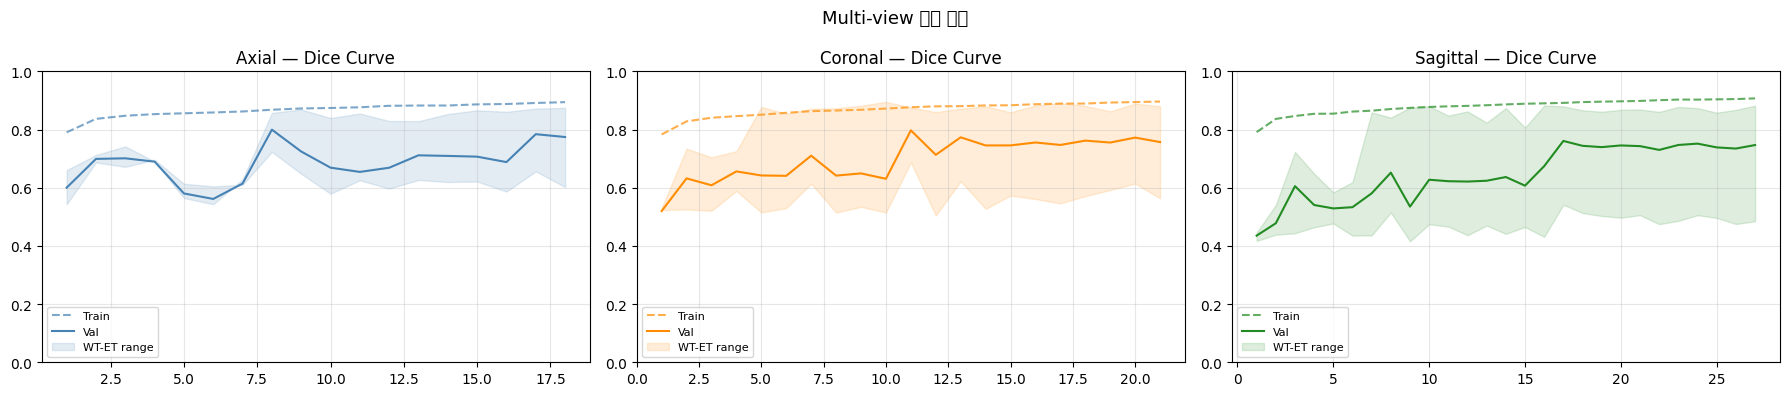

In [28]:
# ── 3개 View 학습 곡선 ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
colors     = {'axial':'steelblue','coronal':'darkorange','sagittal':'forestgreen'}

for ax, view in zip(axes, VIEWS):
    csv_path = WORK_DIR / f'history_multiview_{view}.csv'
    if not csv_path.exists(): continue
    h = pd.read_csv(csv_path)
    ax.plot(h['epoch'], h['train_dice'], label='Train', color=colors[view], linestyle='--', alpha=0.7)
    ax.plot(h['epoch'], h['val_mean'],   label='Val',   color=colors[view])
    ax.fill_between(h['epoch'], h['val_WT'], h['val_ET'], alpha=0.15, color=colors[view], label='WT-ET range')
    ax.set_title(f'{view.capitalize()} — Dice Curve')
    ax.set_ylim(0, 1); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Multi-view 학습 곡선', fontsize=13)
plt.tight_layout()
plt.savefig(WORK_DIR / 'curves_multiview.png', dpi=150, bbox_inches='tight')
plt.show()

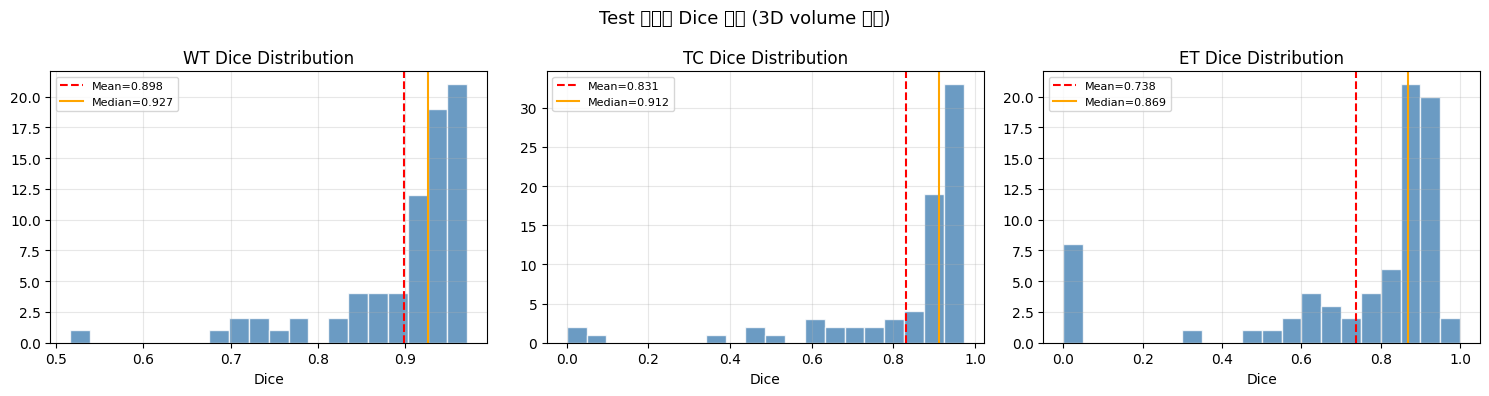

ET Dice 최하위 5 환자:
             patient       WT           TC           ET     mean
BraTS20_Training_279 0.718798 5.278692e-01 2.242655e-10 0.415556
BraTS20_Training_263 0.860450 4.813314e-01 2.407898e-10 0.447260
BraTS20_Training_141 0.892117 8.056719e-11 1.036269e-09 0.297372
BraTS20_Training_272 0.958545 7.992586e-01 1.315789e-09 0.585935
BraTS20_Training_305 0.836800 6.621643e-01 2.564102e-09 0.499655


In [29]:
# ── Test 환자별 Dice 분포 ──────────────────────────────────────
if len(dice_results) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, nm in zip(axes, ['WT','TC','ET']):
        vals = df_res[nm].values
        ax.hist(vals, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
        ax.axvline(vals.mean(), color='red', linestyle='--', label=f'Mean={vals.mean():.3f}')
        ax.axvline(np.median(vals), color='orange', linestyle='-', label=f'Median={np.median(vals):.3f}')
        ax.set_title(f'{nm} Dice Distribution')
        ax.legend(fontsize=8); ax.set_xlabel('Dice'); ax.grid(alpha=0.3)
    plt.suptitle('Test 환자별 Dice 분포 (3D volume 기준)', fontsize=13)
    plt.tight_layout()
    plt.savefig(WORK_DIR / 'dist_multiview_test.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 어려운 케이스 (ET Dice 낮은 환자)
    hard_cases = df_res.nsmallest(5,'ET')[['patient','WT','TC','ET','mean']]
    print('ET Dice 최하위 5 환자:')
    print(hard_cases.to_string(index=False))

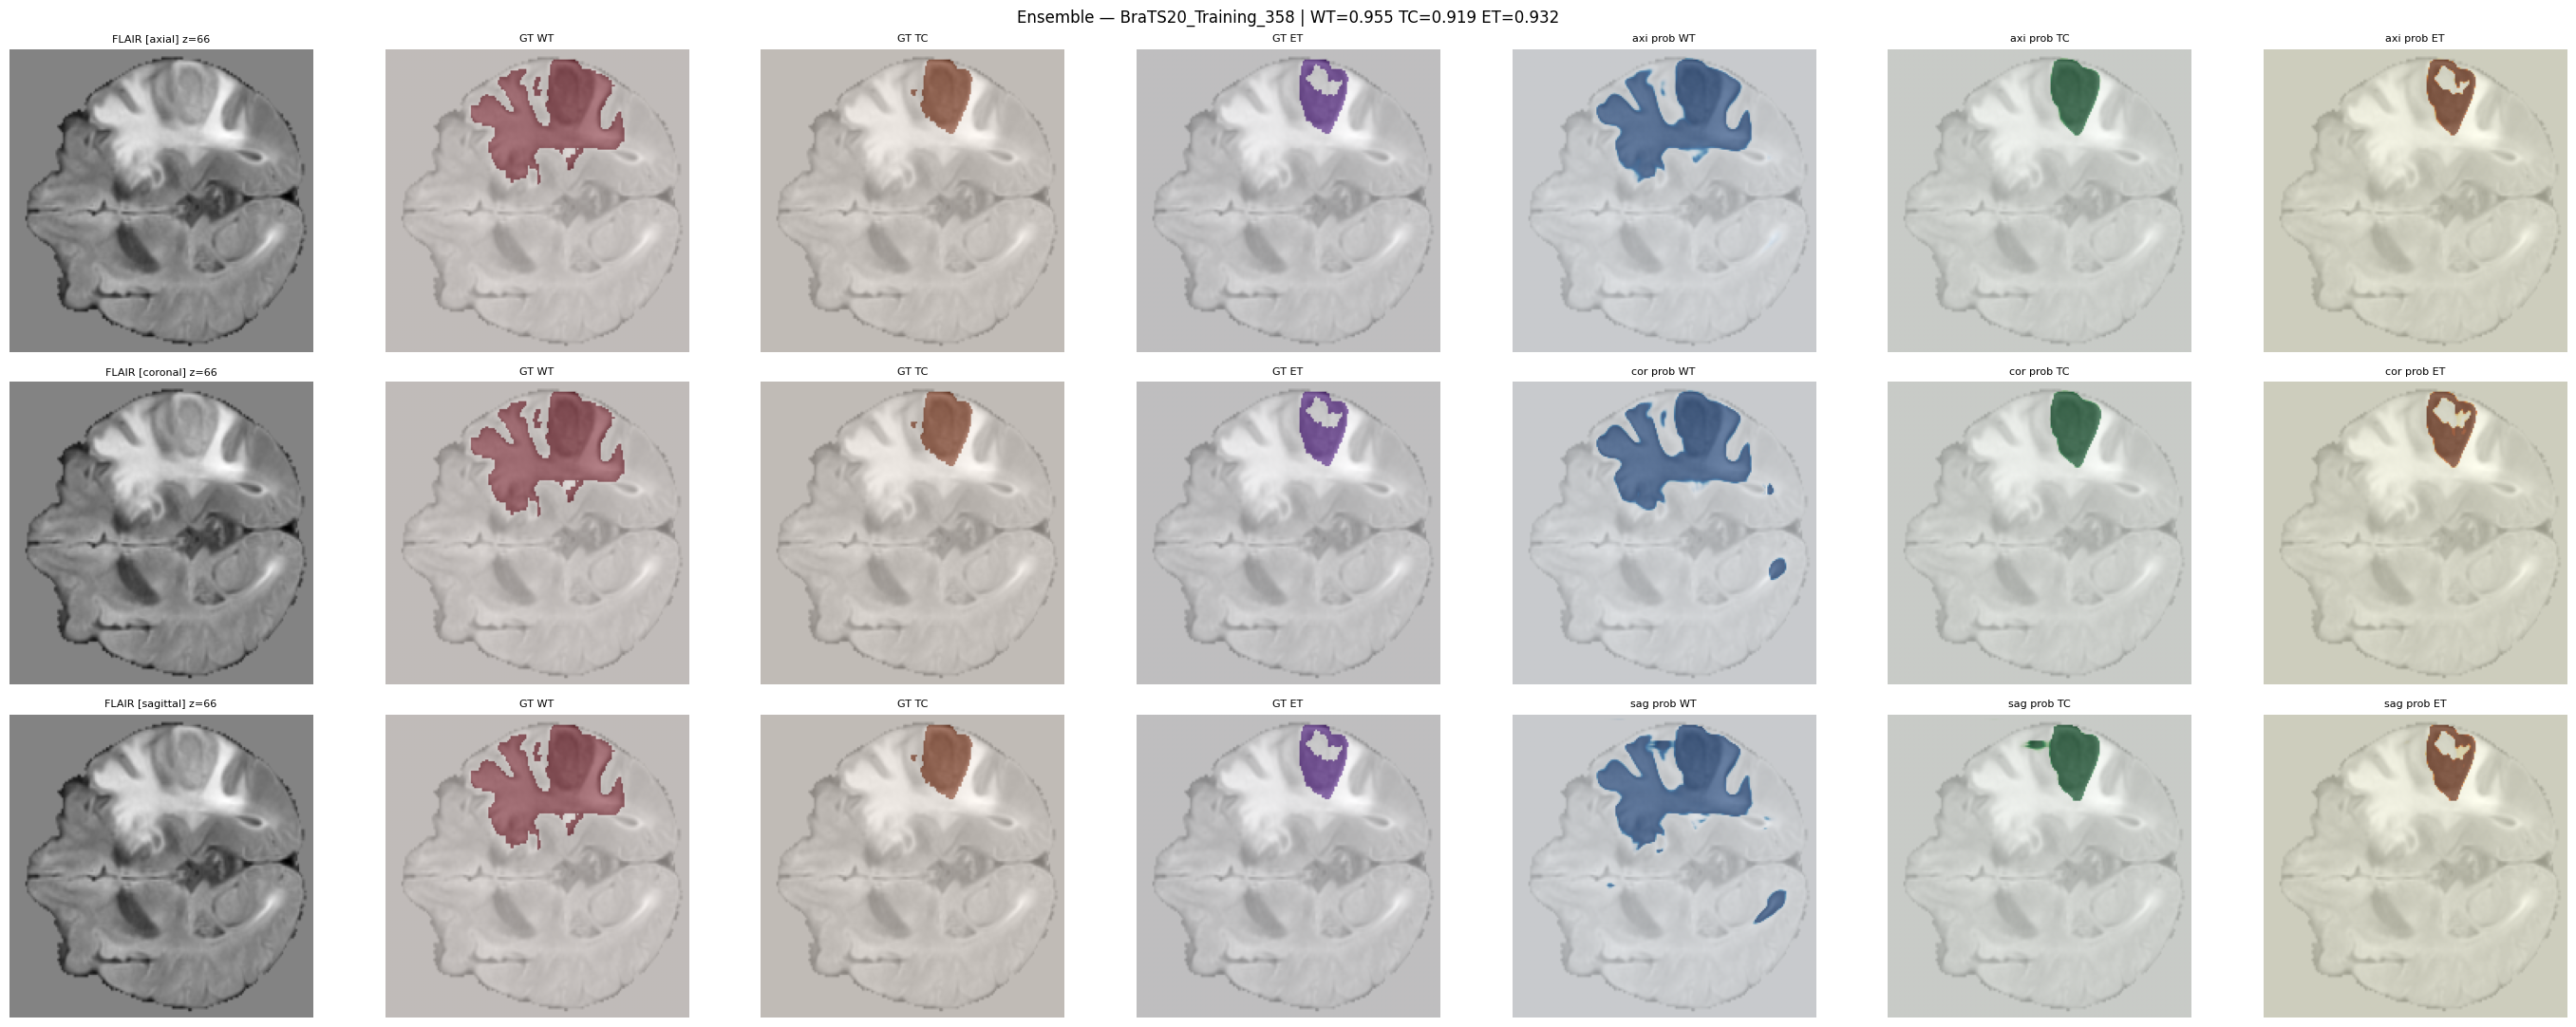

In [30]:
# ── 단일 환자 3-view 시각화 ───────────────────────────────────
def visualize_ensemble_patient(pid, models, ens_weights, device, thr=0.5):
    npz_path = PROC_DIR / 'test' / f'{pid}.npz'
    if not npz_path.exists():
        print(f'{pid} npz 없음'); return
    raw  = np.load(npz_path)
    data = {'image': raw['image'].astype(np.float32), 'mask': raw['mask'].astype(np.float32)}
    mask_reg = data['mask']
    D = mask_reg.shape[2]

    # 종양이 가장 많은 axial slice 선택
    tumor_count = [mask_reg[:,:,z,:].sum() for z in range(D)]
    z_best      = int(np.argmax(tumor_count))

    # 각 view 확률 맵
    prob_vols = {}
    for view in VIEWS:
        prob_vols[view] = reconstruct_3d_prob(models[view], data, view, device)

    prob_ens = sum(ens_weights[v]*prob_vols[v] for v in VIEWS)
    pred_bin = (prob_ens > thr).astype(np.float32)

    # ── 시각화 ──────────────────────────────────────────────────
    flair = data['image'][:,:,z_best,0]   # FLAIR of best axial slice
    gt    = mask_reg[:,:,z_best,:]         # (192,192,3)
    ens_p = prob_ens[:,:,z_best,:]
    cmaps_gt   = ['Reds','Oranges','Purples']
    cmaps_pred = ['Blues','Greens','YlOrBr']

    fig, axes = plt.subplots(3, 7, figsize=(28, 11))
    view_labels = ['Axial prob','Coronal prob','Sagittal prob']
    region_names = ['WT','TC','ET']

    for row_i, view in enumerate(VIEWS):
        pv = prob_vols[view][:,:,z_best,:]
        # Col 0: FLAIR
        axes[row_i,0].imshow(flair,cmap='gray')
        axes[row_i,0].set_title(f'FLAIR [{view}] z={z_best}',fontsize=8)
        axes[row_i,0].axis('off')
        # Col 1-3: GT
        for c in range(3):
            axes[row_i,1+c].imshow(flair,cmap='gray')
            axes[row_i,1+c].imshow(gt[:,:,c],alpha=0.5,cmap=cmaps_gt[c],vmin=0,vmax=1)
            axes[row_i,1+c].set_title(f'GT {region_names[c]}',fontsize=8)
            axes[row_i,1+c].axis('off')
        # Col 4-6: view prob
        for c in range(3):
            axes[row_i,4+c].imshow(flair,cmap='gray')
            axes[row_i,4+c].imshow(pv[:,:,c],alpha=0.6,cmap=cmaps_pred[c],vmin=0,vmax=1)
            axes[row_i,4+c].set_title(f'{view[:3]} prob {region_names[c]}',fontsize=8)
            axes[row_i,4+c].axis('off')

    # 앙상블 결과 (별도 행)
    d3 = dice_3d((prob_ens>thr).astype(np.float32), mask_reg)
    plt.suptitle(f'Ensemble — {pid} | WT={d3["WT"]:.3f} TC={d3["TC"]:.3f} ET={d3["ET"]:.3f}',fontsize=12)
    plt.tight_layout()
    plt.savefig(WORK_DIR/f'viz_ensemble_{pid}.png',dpi=100,bbox_inches='tight')
    plt.show()

# 랜덤 test 환자 시각화
if test_pids:
    sample_pid = random.choice(test_pids)
    visualize_ensemble_patient(sample_pid, models, ens_weights, DEVICE)

In [31]:
# ── 최종 모델 비교 테이블 ──────────────────────────────────────
csv_path = WORK_DIR / 'metrics_all_models.csv'
if csv_path.exists():
    df_all = pd.read_csv(csv_path)
    print('\n모델 비교 (지금까지 실험한 모델 전체)')
    print(df_all[['model','Dice_WT','Dice_TC','Dice_ET','Dice_mean']].to_string(index=False))

print('\n✓ 완료')


모델 비교 (지금까지 실험한 모델 전체)
                  model  Dice_WT  Dice_TC  Dice_ET  Dice_mean
            2.5D_UNetPP   0.6095   0.7553   0.7631     0.7093
MultiView_Ensemble_2.5D   0.8984   0.8309   0.7379     0.8224

✓ 완료
